# House Price Prediction Linear Regression

In [54]:
# importing libraries
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import r2_score

In [15]:
# importing cleaned dataset
df = pd.read_csv('cleaned_housing.csv')
df.shape

(545, 13)

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [22]:
# train test split
y = df['price']
X = df.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=104,
                                                    test_size=0.25, shuffle=True)

In [26]:
print('X_train : ')
print(X_train.head())
print(X_train.shape)

print('')
print('X_test : ')
print(X_test.head())
print(X_test.shape)

print('')
print('y_train : ')
print(y_train.head())
print(y_train.shape)

print('')
print('y_test : ')
print(y_test.head())
print(y_test.shape)

X_train : 
     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
425  3185         2          1        1         1          0         1   
491  2640         2          1        1         0          0         0   
494  6800         2          1        1         1          0         0   
485  3630         2          1        1         1          0         0   
239  4000         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
425                0                0        2         0                 2  
491                0                0        1         0                 2  
494                0                0        0         0                 0  
485                0                0        0         0                 0  
239                0                0        1         0                 2  
(408, 12)

X_test : 
     area  bedrooms  bathrooms  stories  mainroad  guestroom 

In [38]:
# model building
model = LinearRegression(fit_intercept=True)
model.fit(X,y)
predictions = model.predict(X_test)

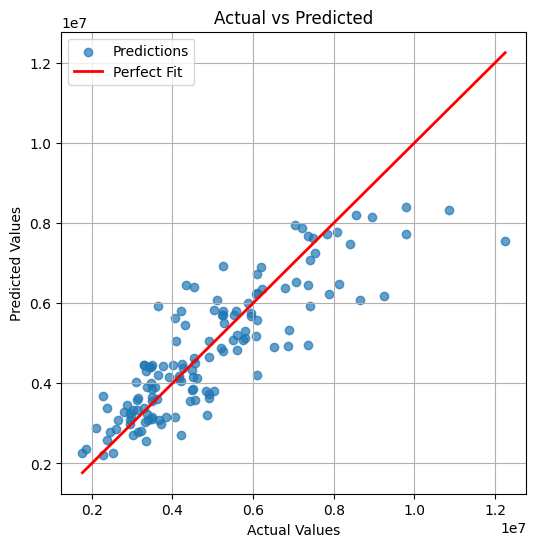

In [41]:
# plot between predicted and actual values
# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.7, label="Predictions")

# Perfect prediction line (y = x)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Perfect Fit')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# testing the model
X_test.head(1)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
49,7440,3,2,1,1,1,1,0,1,0,1,1


In [49]:
y_test.head(1)

,price
49,7420000


In [53]:
test_house = [[7440, 3, 2, 1, 1, 1, 1, 0, 1, 0, 1, 1]]
np.floor(model.predict(test_house))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7069684.])

In [59]:
r2 = r2_score(y_test, predictions)
r2*100

72.85698936680835